# EDA PARA DATASET DE ATAQUES DE CIBERSEGURIDAD — VERSIÓN CORREGIDA
## FUENTE: https://www.kaggle.com/datasets/tannubarot/cybersecurity-attack-and-defence-dataset/data

# IMPORTAMOS LIBRERIAS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# CARGAMOS DATASET

In [ ]:
import kagglehub
path = kagglehub.dataset_download('tannubarot/cybersecurity-attack-and-defence-dataset')
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cybersecurity-attack-and-defence-dataset' dataset.
Path to dataset files: /kaggle/input/cybersecurity-attack-and-defence-dataset


In [ ]:
!ls /root/.cache/kagglehub/datasets/tannubarot/cybersecurity-attack-and-defence-dataset/versions/2

Attack_Dataset.csv


In [ ]:
df = pd.read_csv(path + '/Attack_Dataset.csv')

# Local:
# df = pd.read_csv('Attack_Dataset.csv')
# df.head()

Using Colab cache for faster access to the 'cybersecurity-attack-and-defence-dataset' dataset.


In [ ]:
df

,ID,Title,Category,Attack Type,Scenario Description,Tools Used,Attack Steps,Target Type,Vulnerability,MITRE Technique,Impact,Detection Method,Solution,Tags,Source,Unnamed: 15
0,1,Authentication Bypass via SQL Injection,Mobile Security,SQL Injection (SQLi),A login form fails to validate or sanitize inp...,"Browser, Burp Suite, SQLMap",1. Reconnaissance: Find a login form on the we...,"Web Login Portals (e.g., banking, admin dashbo...",Unsanitized input fields in SQL queries,"T1078 (Valid Accounts), T1190 (Exploit Public-...","Full account takeover, data theft, privilege e...","Web server logs, anomaly detection (e.g., logi...","Use prepared statements, Sanitize inputs, Limi...","SQLi, Authentication Bypass, Web Security, OWA...","OWASP, MITRE ATT&CK, DVWA",NaN
1,2,Union-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when a hacker uses the SQL ...,"SQLMap, Burp Suite, Havij, Browser Developer T...",1. Identify User Input Points: Attacker finds ...,"Web Applications, Login Pages, Search Forms",Improperly filtered input fields that allow SQ...,T1190 – Exploit Public-Facing Application,"Data leakage, Credential theft, Account takeov...",Web Application Firewalls (WAF)Log AnalysisInp...,Use parameterized queries (Prepared Statements...,#SQLInjection #WebSecurity #UnionAttack #OWASP...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN
2,3,Error-Based SQL Injection,AI Agents & LLM Exploits,SQL Injection,This attack occurs when an attacker intentiona...,"SQLMap, Burp Suite, Manual Browser Testing, Havij",1. Identify Input Points:Attacker finds a fiel...,"Web Applications, Login Forms, URL Parameters,...",Error message exposure due to lack of input va...,T1190 – Exploit Public-Facing Application,"Information disclosure, Database structure exp...",Review and monitor error logsEnable generic er...,Turn off detailed error messages in production...,#SQLInjection #ErrorLeakage #WebAppSecurity #O...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger Web...",NaN
3,4,Blind SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In Blind SQL Injection, the attacker doesn’t s...","SQLMap, Burp Suite, sqlninja, Manual Browser T...",1. Find a User Input Point:Attacker finds a pl...,"Web Applications, Login Pages, Search Fields, ...","No error messages, but user input is still pas...",T1190 – Exploit Public-Facing Application,Slow and stealthy data theftFull database comp...,Monitor for slow and repetitive requestsAnalyz...,Use parameterized queries (prepared statements...,#BlindSQLi #TimeBasedSQLi #WebAppSecurity #OWA...,"OWASP, MITRE ATT&CK, Acunetix, PortSwigger, SQ...",NaN
4,5,Second-Order SQL Injection,AI Agents & LLM Exploits,SQL Injection,"In a Second-Order SQL Injection, the attacker ...","Burp Suite, SQLMap, Postman, Browser Dev Tools...",1. Identify Stored Input Fields:The attacker l...,"Web Applications, User Registration Forms, Pro...",Trusting previously stored unvalidated data in...,T1505.003 – SQL Injection,Delayed data theftUnexpected system behaviorSe...,Log monitoring for delayed query failuresTrack...,Sanitize and validate inputs both at entry and...,#SecondOrderSQLi #DelayedInjection #StoredInje...,"OWASP, MITRE ATT&CK, PortSwigger Academy, Acun...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14128,14129,Machine Learning-Based Detection of Satellite ...,Satellite & Space Infrastructure Security,Simulation of Satellite Attacks,Researching machine learning models to classif...,"Scikit-learn, TensorFlow, GMAT",1. Simulate spoofed and legitimate satellite t...,Simulated Satellite Telemetry,Pattern Anomaly,T1609.002,Early spoof detection,ML detection accuracy benchmarks,AI-aided signal anomaly defense,"ML, spoofing, telemetry, AI",Research Lab Experiment,NaN
14129,14130,Live Inter-Agency Workshop for Satellite Attac...,Satellite & Space Infrastructure Security,Cross-Domain Collaboration,Organizing hands-on workshop between agencies ...,"Tabletop Kits, Shared Scenarios",1. Host a 

# EDA

## INSPECCIÓN INICIAL

In [ ]:
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
print('\nTipos de datos:')
print(df.dtypes)

Filas: 14133 | Columnas: 16

Tipos de datos:
ID                       int64
Title                   object
Category                object
Attack Type             object
Scenario Description    object
Tools Used              object
Attack Steps            object
Target Type             object
Vulnerability           object
MITRE Technique         object
Impact                  object
Detection Method        object
Solution                object
Tags                    object
Source                  object
Unnamed: 15             object
dtype: object


## TRATAMIENTO DE NULOS

In [ ]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'nulos': nulos, 'porcentaje': pct_nulos})
resumen_nulos = resumen_nulos[resumen_nulos['nulos'] > 0].sort_values('porcentaje', ascending=False)
print(resumen_nulos)

                  nulos  porcentaje
Unnamed: 15       14087       99.67
Source              160        1.13
MITRE Technique      24        0.17
Vulnerability        18        0.13
Tools Used           14        0.10
Target Type           4        0.03
Detection Method      4        0.03
Impact                3        0.02
Tags                  3        0.02
Solution              3        0.02


In [ ]:
%run '/content/pandas_missing_extension.ipynb'

In [ ]:
df.missing.number_missing()

np.int64(14320)

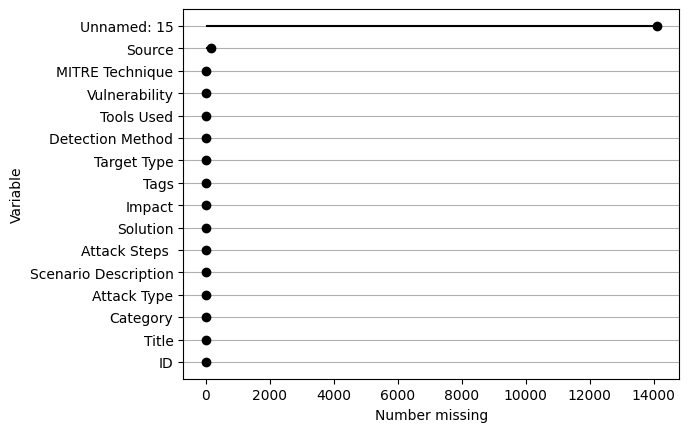

In [ ]:
df.missing.missing_variable_plot()

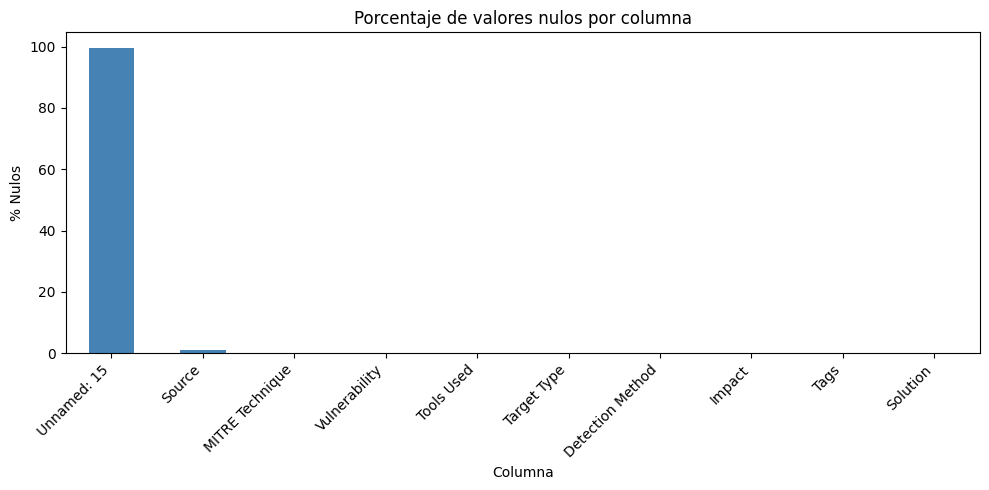

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
pct_nulos_all = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
pct_nulos_all[pct_nulos_all > 0].plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Porcentaje de valores nulos por columna')
ax.set_ylabel('% Nulos')
ax.set_xlabel('Columna')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Axes: >

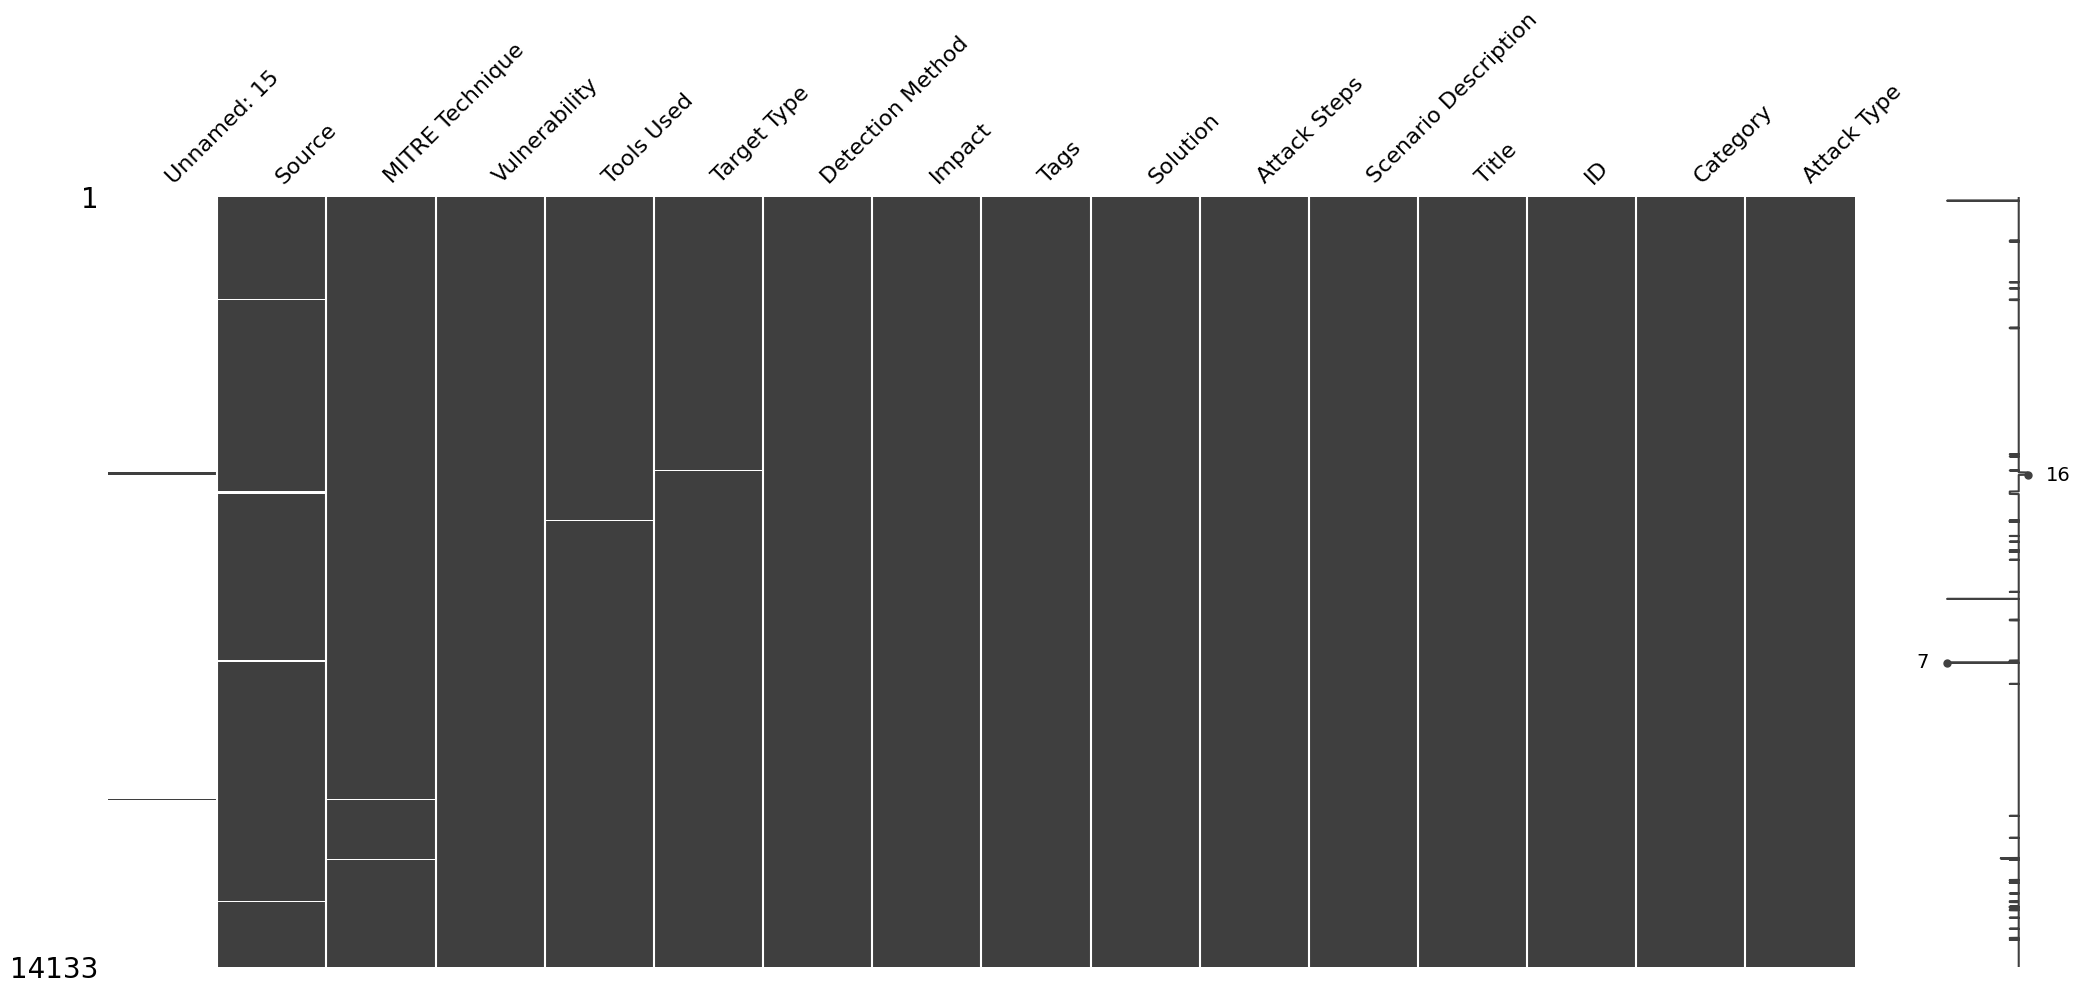

In [ ]:
import missingno

df.missing.sort_variables_by_missingness().pipe(missingno.matrix)

In [ ]:
df_cleaned = df.copy()

# 'Unnamed: 15' tiene 99.6% de nulos — se elimina la columna
df_cleaned = df_cleaned.drop(columns=['Unnamed: 15'])
print(f'Shape resultante: {df_cleaned.shape}')

Columna 'Unnamed: 15' eliminada.
Shape resultante: (14133, 15)


## IMPUTACIÓN DE VARIABLES CATEGÓRICAS

In [ ]:
df.dtypes

,0
ID,int64
Title,object
Category,object
Attack Type,object
Scenario Description,object
Tools Used,object
Attack Steps,object
Target Type,object
Vulnerability,object
MITRE Technique,object


In [ ]:
columnas_categoricas = df_cleaned.select_dtypes(include='object').columns.tolist()
print(f'Columnas categóricas a imputar: {columnas_categoricas}')

for col in columnas_categoricas:
    if df_cleaned[col].isnull().sum() > 0:
        moda = df_cleaned[col].mode()[0]
        df_cleaned[col] = df_cleaned[col].fillna(moda)
        print(f'  [{col}] imputado con moda: "{moda}"')

Columnas categóricas a imputar: ['Title', 'Category', 'Attack Type', 'Scenario Description', 'Tools Used', 'Attack Steps ', 'Target Type', 'Vulnerability', 'MITRE Technique', 'Impact', 'Detection Method', 'Solution', 'Tags', 'Source']
  [Tools Used] imputado con moda: "Velociraptor"
  [Target Type] imputado con moda: "Windows"
  [Vulnerability] imputado con moda: "PLC"
  [MITRE Technique] imputado con moda: "T1203"
  [Impact] imputado con moda: "Credential theft"
  [Detection Method] imputado con moda: "Registry + Prefetch + Memory"
  [Solution] imputado con moda: "Disable debug ports in production"
  [Tags] imputado con moda: "GPS spoofing, mobile fraud"
  [Source] imputado con moda: "Simulated"


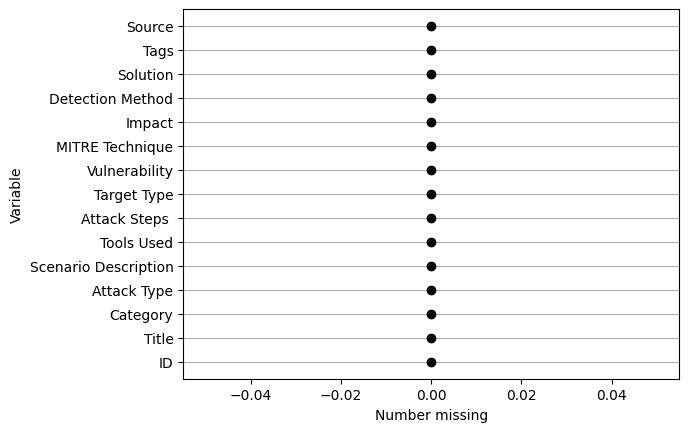

In [ ]:
df_cleaned.missing.missing_variable_plot()

In [ ]:
df_cleaned.missing.number_missing()

np.int64(0)

In [ ]:
print('Nulos restantes:')
print(df_cleaned.isnull().sum().sum())

Nulos restantes:
0


## ANÁLISIS OUTLIERS — SOLO VARIABLES NUMÉRICAS REALES

In [ ]:
numericas_reales = [col for col in df_cleaned.select_dtypes(include=np.number).columns if col != 'ID']

if not numericas_reales:
    print('Este dataset no tiene variables numéricas analíticas además de ID.')
    print('El análisis de outliers y dispersión aplica a las variables categóricas mediante frecuencias.')
else:
    for variable in numericas_reales:
        data = df_cleaned[variable]
        print(f'\n=== {variable} ===')
        print(f'Media: {data.mean():.2f} | Mediana: {data.median():.2f} | Moda: {data.mode()[0]:.2f}')

Este dataset no tiene variables numéricas analíticas además de ID.
El análisis de outliers y dispersión aplica a las variables categóricas mediante frecuencias.


## EDA DE VARIABLES CATEGÓRICAS
### Este es el análisis central del dataset — toda la información útil está en las categorías

In [ ]:
# Función reutilizable para graficar distribución de categorías
def plot_categoria(df, columna, top_n=10, titulo=None):
    conteo = df[columna].value_counts().head(top_n)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Barras
    sns.barplot(x=conteo.values, y=conteo.index, palette='Blues_r', ax=axes[0])
    axes[0].set_title(f'Top {top_n} - {columna}')
    axes[0].set_xlabel('Frecuencia')

    # Torta
    axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.1f%%', startangle=140)
    axes[1].set_title(f'Distribución - {columna}')

    plt.suptitle(titulo or columna, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(conteo.to_string())
    print()

/tmp/ipykernel_5844/653292534.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.values, y=conteo.index, palette='Blues_r', ax=axes[0])


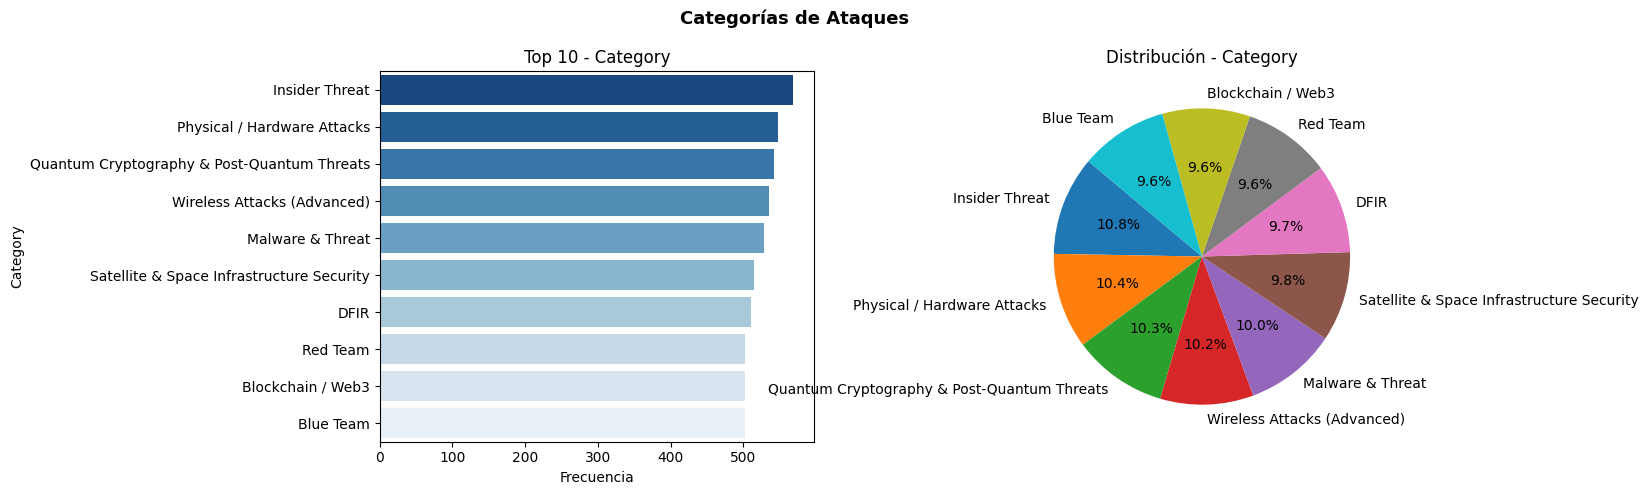

Category
Insider Threat                                 569
Physical / Hardware Attacks                    548
Quantum Cryptography & Post-Quantum Threats    542
Wireless Attacks (Advanced)                    535
Malware & Threat                               528
Satellite & Space Infrastructure Security      515
DFIR                                           510
Red Team                                       503
Blockchain / Web3                              503
Blue Team                                      503



In [ ]:
plot_categoria(df_cleaned, 'Category', top_n=10, titulo='Categorías de Ataques')

/tmp/ipykernel_5844/653292534.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.values, y=conteo.index, palette='Blues_r', ax=axes[0])


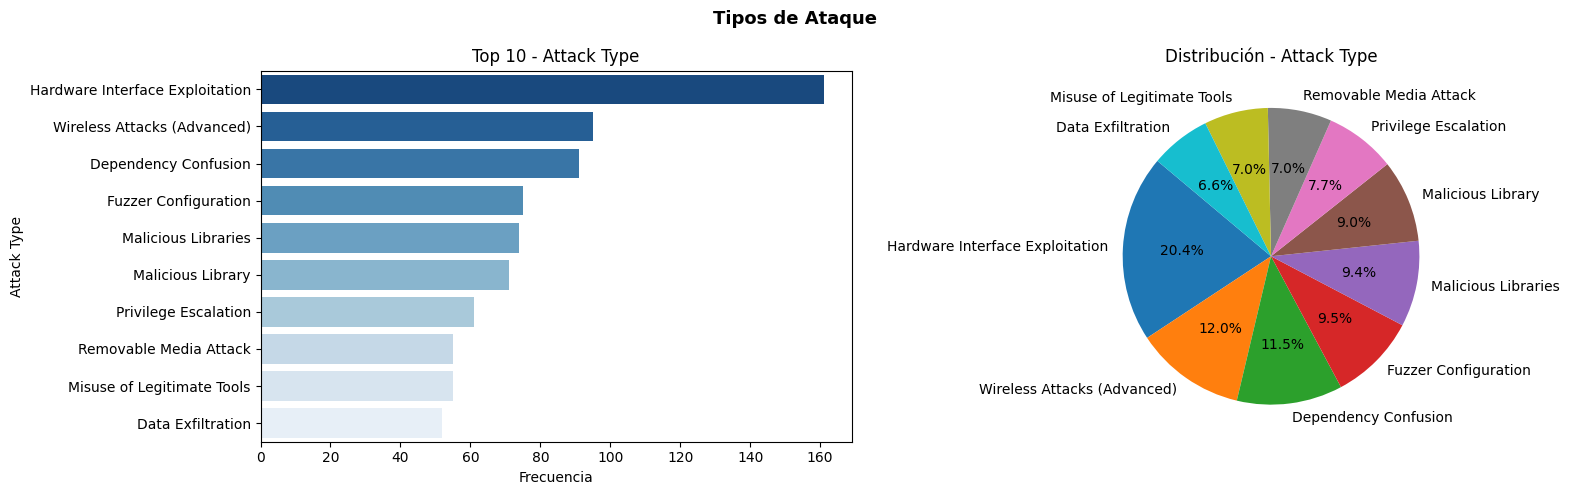

Attack Type
Hardware Interface Exploitation    161
Wireless Attacks (Advanced)         95
Dependency Confusion                91
Fuzzer Configuration                75
Malicious Libraries                 74
Malicious Library                   71
Privilege Escalation                61
Removable Media Attack              55
Misuse of Legitimate Tools          55
Data Exfiltration                   52



In [ ]:
plot_categoria(df_cleaned, 'Attack Type', top_n=10, titulo='Tipos de Ataque')

/tmp/ipykernel_5844/653292534.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.values, y=conteo.index, palette='Blues_r', ax=axes[0])


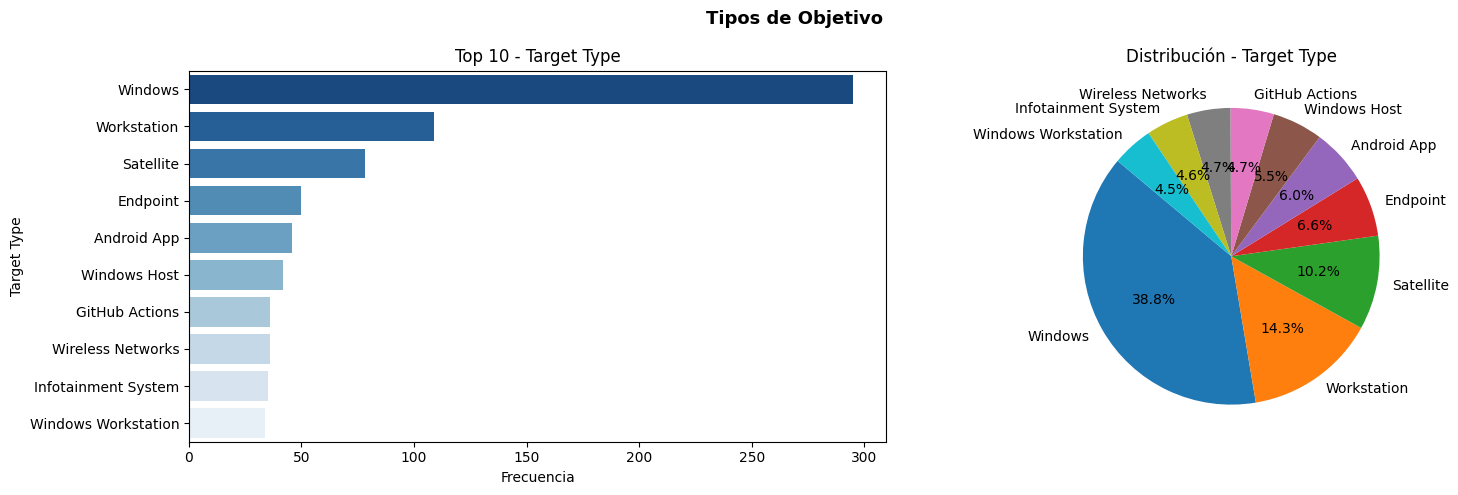

Target Type
Windows                295
Workstation            109
Satellite               78
Endpoint                50
Android App             46
Windows Host            42
GitHub Actions          36
Wireless Networks       36
Infotainment System     35
Windows Workstation     34



In [ ]:
plot_categoria(df_cleaned, 'Target Type', top_n=10, titulo='Tipos de Objetivo')

/tmp/ipykernel_5844/653292534.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.values, y=conteo.index, palette='Blues_r', ax=axes[0])


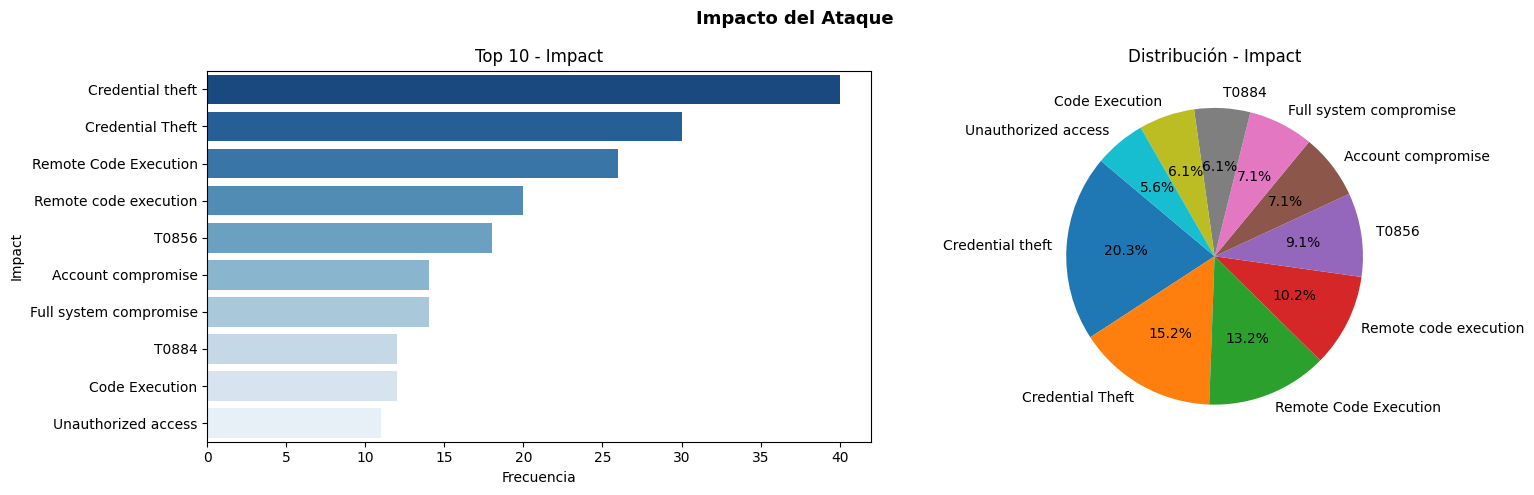

Impact
Credential theft          40
Credential Theft          30
Remote Code Execution     26
Remote code execution     20
T0856                     18
Account compromise        14
Full system compromise    14
T0884                     12
Code Execution            12
Unauthorized access       11



In [ ]:
plot_categoria(df_cleaned, 'Impact', top_n=10, titulo='Impacto del Ataque')

/tmp/ipykernel_5844/653292534.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.values, y=conteo.index, palette='Blues_r', ax=axes[0])


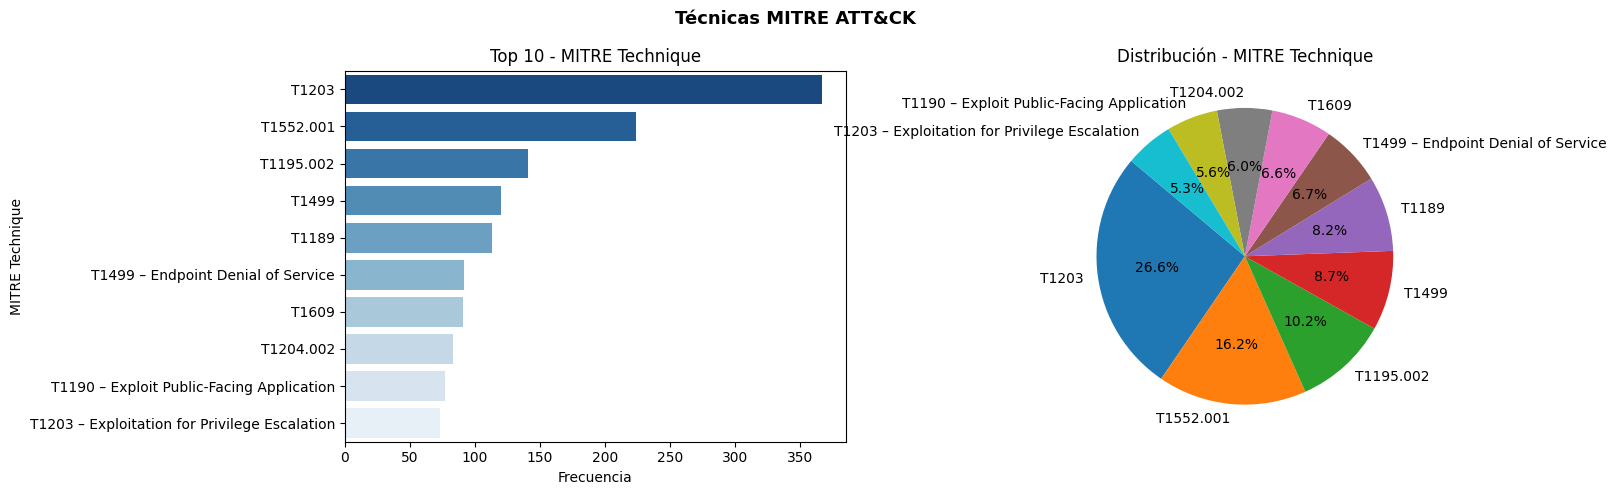

MITRE Technique
T1203                                            367
T1552.001                                        224
T1195.002                                        141
T1499                                            120
T1189                                            113
T1499 – Endpoint Denial of Service                92
T1609                                             91
T1204.002                                         83
T1190 – Exploit Public-Facing Application         77
T1203 – Exploitation for Privilege Escalation     73



In [ ]:
plot_categoria(df_cleaned, 'MITRE Technique', top_n=10, titulo='Técnicas MITRE ATT&CK')

## GUARDAMOS DATASET LIMPIO

In [ ]:
df_cleaned.to_csv('attack_dataset_cleaned_v2.csv', index=False)
print(f'Dataset guardado. Shape final: {df_cleaned.shape}')

Dataset guardado. Shape final: (14133, 15)
